# Regresión Lineal con Python
Aplicando las librerías de `numpy` y `pandas` para manipular los datos, y `matplotlib` para replicar el estilo visual del gráfico.

## Regresión Lineal con dataset sintético
### Características a implementar

* **Dataset fiel:** Los valores de $X$ se acotan estrictamente entre 10 y 50 usando una distribución uniforme.
* **Fórmula matemática exacta:** Los puntos $Y$ se desvían de manera controlada usando ruido estadístico gausiano (`np.random.normal`) centrado sobre la recta dada.
* **Paleta y diseño:** Se empleran los códigos hexadecimales exactos para los puntos azul claro (`#8cb3ef`), el contorno oscuro, la línea roja (`#e74c3c`) y la eliminación de los bordes externos innecesarios de la gráfica.

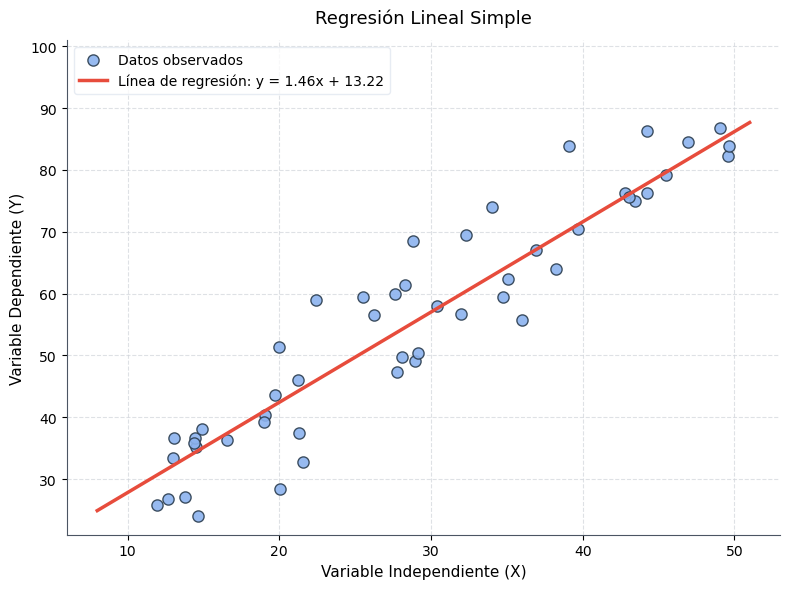

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración de aleatoriedad para reproducibilidad
np.random.seed(45)

# 2. Generación del dataset sintético (50 puntos de datos)
X = np.random.uniform(10, 50, size=50)

# Generamos Y usando la ecuación de la recta (y = 1.46x + 13.22) + ruido aleatorio
ruido = np.random.normal(0, 7.5, size=50)
Y = 1.46 * X + 13.22 + ruido

# 3. Puntos extremos para trazar la línea de regresión continua
X_linea = np.linspace(8, 51, 100)
Y_linea = 1.46 * X_linea + 13.22

# 4. Construcción y estilizado de la gráfica con Matplotlib
plt.figure(figsize=(8, 6))

# Dibujar los puntos dispersos (Datos observados)
plt.scatter(X, Y, color='#8cb3ef', edgecolor='#2c3e50', s=65, alpha=0.9, label='Datos observados', zorder=3)

# Dibujar la recta de regresión
plt.plot(X_linea, Y_linea, color='#e74c3c', linewidth=2.5, label='Línea de regresión: y = 1.46x + 13.22', zorder=4)

# Personalización de títulos y etiquetas de los ejes
plt.title('Regresión Lineal Simple', fontsize=13, pad=12, fontweight='normal')
plt.xlabel('Variable Independiente (X)', fontsize=11)
plt.ylabel('Variable Dependiente (Y)', fontsize=11)

# Configuración de límites y cuadrícula (Estilo idéntico a la imagen)
plt.xlim(6, 53)
plt.ylim(21, 101)
plt.grid(True, linestyle='--', color='#d1d5db', alpha=0.7, zorder=1)

# Estilo de la leyenda
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e2e8f0', fontsize=10)

# Limpieza estética del marco (remover líneas superior y derecha)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#4b5563')
ax.spines['bottom'].set_color('#4b5563')

# Mostrar el gráfico en pantalla
plt.tight_layout()
plt.show()

## Regresión Lineal con dataset
### Características a implementar

El dataset `00.dataset_regresion_lineal.csv` contiene la tabla limpia con las columnas estructurales del problema simulado: don la `Variable_Independiente_X` (valores aleatorios continuos) y la `Variable_Dependiente_Y` (calculada usando el sesgo matemático y la varianza simulada).

Con **Python** integramos la persistencia de datos en el CSV y aplicamos la librería [scikit-learn](https://scikit-learn.org/) para ajustar de forma oficial la línea recta y calcular el coeficiente de determinación ($R^2$):

¡Dataset exportado exitosamente a '00.dataset_regresion_lineal.csv'!
Coeficiente de determinación (R²): 0.8830


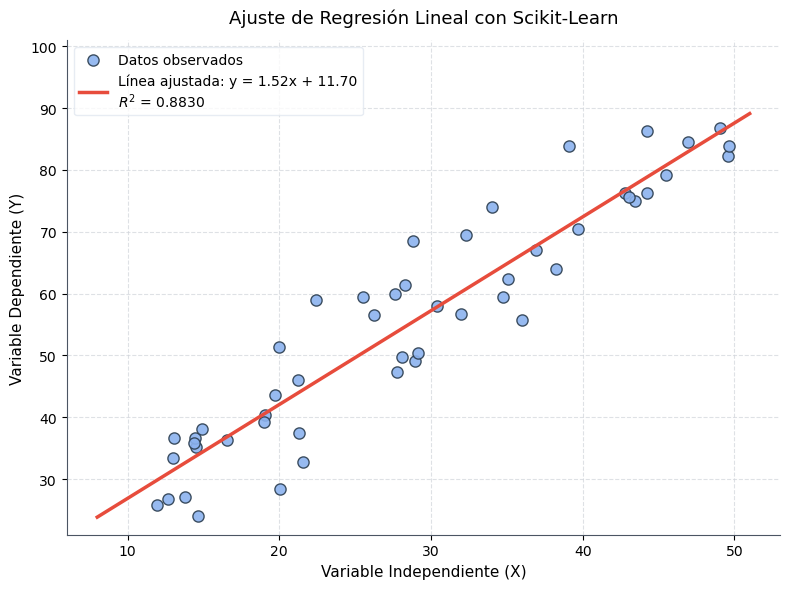

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Fijar semilla para garantizar consistencia estadística
np.random.seed(45)

# 2. Generar el dataset controlado (50 registros)
X = np.random.uniform(10, 50, size=50)
ruido = np.random.normal(0, 7.5, size=50)
Y = 1.46 * X + 13.22 + ruido

# 3. Guardar el dataset estructurado en un archivo CSV limpio
df = pd.DataFrame({'Variable_Independiente_X': X, 'Variable_Dependiente_Y': Y})
df.to_csv('00.dataset_regresion_lineal.csv', index=False)
print("¡Dataset exportado exitosamente a '00.dataset_regresion_lineal.csv'!")

# 4. Formatear vectores para el entrenamiento en Scikit-Learn
# Scikit-learn requiere que las variables predictoras (X) tengan dos dimensiones
X_reshaped = X.reshape(-1, 1)

# 5. Inicializar y ajustar el modelo lineal matemático
modelo = LinearRegression()
modelo.fit(X_reshaped, Y)

# 6. Predecir los valores estimados de Y sobre nuestra muestra original
Y_predichas = modelo.predict(X_reshaped)

# 7. Calcular métrica clave: Coeficiente de determinación (R-cuadrado)
coeficiente_r2 = r2_score(Y, Y_predichas)
print(f"Coeficiente de determinación (R²): {coeficiente_r2:.4f}")

# 8. Renderizar el gráfico técnico integrando el R² obtenido
X_linea = np.linspace(8, 51, 100)
Y_linea = modelo.predict(X_linea.reshape(-1, 1))

plt.figure(figsize=(8, 6))

# Puntos de datos observados
plt.scatter(X, Y, color='#8cb3ef', edgecolor='#2c3e50', s=65, alpha=0.9, label='Datos observados', zorder=3)

# Línea del modelo e información de bondad de ajuste en la leyenda
leyenda_linea = f'Línea ajustada: y = {modelo.coef_[0]:.2f}x + {modelo.intercept_:.2f}\n$R^2$ = {coeficiente_r2:.4f}'
plt.plot(X_linea, Y_linea, color='#e74c3c', linewidth=2.5, label=leyenda_linea, zorder=4)

# Estética y configuración de ejes
plt.title('Ajuste de Regresión Lineal con Scikit-Learn', fontsize=13, pad=12)
plt.xlabel('Variable Independiente (X)', fontsize=11)
plt.ylabel('Variable Dependiente (Y)', fontsize=11)
plt.xlim(6, 53)
plt.ylim(21, 101)
plt.grid(True, linestyle='--', color='#d1d5db', alpha=0.7, zorder=1)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e2e8f0', fontsize=10)

# Limpieza de la interfaz gráfica
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#4b5563')
ax.spines['bottom'].set_color('#4b5563')

plt.tight_layout()
plt.show()


### Explicación técnicos:

* **`LinearRegression()`**: Construye el optimizador matemático por el método clásico de mínimos cuadrados ordinarios. Encuentra de forma automatizada los valores óptimos de la pendiente y la intersección.
* **`r2_score(Y, Y_predichas)`**: Evalúa matemáticamente qué porcentaje de la dispersión total de tus datos es explicada por la línea recta. Devuelve un valor decimal entre 0 y 1 (donde un valor más alto denota mayor precisión en la proyección).
* **Dinámica en Leyenda**: La gráfica calcula automáticamente la etiqueta roja usando las variables internas del objeto matemático entrenado (`modelo.coef_[0]` y `modelo.intercept_`), junto a su respectivo resultado estadístico final de ajuste.